In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Step 1: Data Triage, Feature Engineering & The RFM Framework**

In [ ]:
import pandas as pd
import numpy as np

# Loading the Data
file_path = '/content/drive/MyDrive/Data Science Projects/Customer Lifetime Value Forecasting/ecommerce_customer_behavior_dataset_v2.csv'
data = pd.read_csv(file_path, sep=',');
df = data.copy()
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


# Details about Column Names


* **Order_ID** - Unique identifier for each transaction
* **Customer_ID** - Unique identifier for each customer
* **Date** - Transaction date when the order was placed
* **Age** - Customer's age in years
* **Gender** - Customer's gender
* **City** - Customer's city location in Turkey
* **Product_Category** - Category of purchased product
* **Unit_Price** - Price per unit of the product in Turkish Lira (TRY)
* **Quantity** - Number of units purchased in the transaction
* **Discount_Amount** - Total discount applied to the order in TRY
* **Total_Amount** - Final amount paid after discount
* **Payment_Method** - Method used for payment
* **Device_Type** - Device used to make the purchase
* **Session_Duration_Minutes** - Time spent on website during the session in minutes
* **Pages_Viewed** - Number of pages viewed during the shopping session
* **Is_Returning_Customer** - Whether the customer has made previous purchases
* **Delivery_Time_Days** - Number of days taken to deliver the order
* **Customer_Rating** - Customer satisfaction rating for the order

In [ ]:
import pandas as pd
import numpy as np

df['Date'] = pd.to_datetime(df['Date'])

# 1) Splitting Prediction Days and Cutoff Days
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)
prediction_days = 90
cutoff_date = snapshot_date - pd.Timedelta(days=prediction_days)

df_features = df[df['Date'] < cutoff_date]
df_target = df[df['Date'] >= cutoff_date]

def get_mode(x):
  return x.mode()[0] if not x.mode().empty else np.nan

customer_features = df_features.groupby('Customer_ID').agg({
    'Date': lambda x: (cutoff_date - x.max()).days,
    'Order_ID': 'count',
    'Unit_Price': 'mean',
    'Session_Duration_Minutes': 'mean',
    'Delivery_Time_Days': 'mean',
    'Customer_Rating': 'mean',
    'Age': 'first',
    'Payment_Method': get_mode,
}).reset_index()

customer_features.rename(columns={
    'Date': 'Recency_Days',
    'Order_ID': 'Frequency',
    'Session_Duration_Minutes': 'Avg_Session_Duration',
    'Delivery_Time_Days': 'Avg_Delivery_Time',
    'Customer_Rating':'Avg_Customer_Rating',
    'Unit_Price': 'Avg_Unit_Price',
    'Payment_Method': 'Preferred_Payment'
}, inplace=True)

customer_target = df_target.groupby('Customer_ID').agg({
    'Total_Amount': 'sum'
}).reset_index()

customer_target.rename(columns={'Total_Amount': 'Monetary_CLV'}, inplace=True)

customer_df = pd.merge(customer_features, customer_target, on='Customer_ID', how='left')
customer_df['Monetary_CLV'] = customer_df['Monetary_CLV'].fillna(0)

print(f"The Shape of Original DF: {df.shape}")
print(f"The Shape of 'customer_df': {customer_df.shape}")

The Shape of Original DF: (17049, 18)
The Shape of 'customer_df': (4759, 10)


In [ ]:
import numpy as np
import pandas as pd

# Let's see the actual TL limits of your buyers
real_spenders = customer_df[customer_df['Monetary_CLV'] > 0]['Monetary_CLV']

print("--- The Wealth Distribution of Your Buyers ---")
print(f"50th Percentile (The Median Customer): {np.percentile(real_spenders, 50):,.2f} TL")
print(f"75th Percentile (Upper Middle Class):  {np.percentile(real_spenders, 75):,.2f} TL")
print(f"90th Percentile (The High Rollers):    {np.percentile(real_spenders, 90):,.2f} TL")
print(f"95th Percentile (The Mini-Whales):     {np.percentile(real_spenders, 95):,.2f} TL")
print(f"99th Percentile (The Mega-Whales):     {np.percentile(real_spenders, 99):,.2f} TL")
print(f"The Absolute Maximum Spender:          {real_spenders.max():,.2f} TL")

--- The Wealth Distribution of Your Buyers ---
50th Percentile (The Median Customer): 691.52 TL
75th Percentile (Upper Middle Class):  2,033.71 TL
90th Percentile (The High Rollers):    4,908.48 TL
95th Percentile (The Mini-Whales):     7,380.03 TL
99th Percentile (The Mega-Whales):     14,875.32 TL
The Absolute Maximum Spender:          33,622.83 TL


# **Step 2: Probability Distributions & Target Transformation.**

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew

# 1) Calculating the Skew and Logarithmic Transformation
original_skew = skew(customer_df['Monetary_CLV'])
print(f"Original Skewness: {original_skew:.4f}")

customer_df['Log_Monetary_CLV'] = np.log1p(customer_df['Monetary_CLV'])
log_skew = skew(customer_df['Log_Monetary_CLV'])
print(f"Log Transformed Skewness: {log_skew:.4f}")

Original Skewness: 5.2632
Log Transformed Skewness: 0.3985


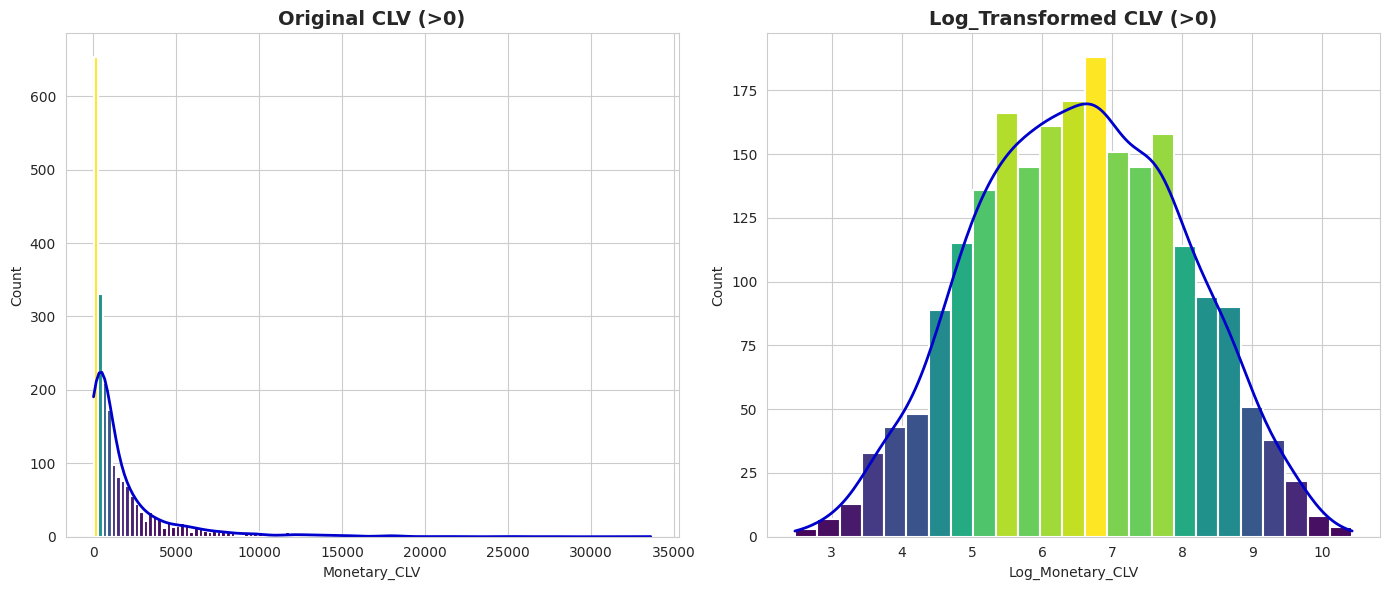

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

active_customers = customer_df[customer_df['Monetary_CLV'] > 0]

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Original CLV Distribution
ax1 = sns.histplot(active_customers['Monetary_CLV'], kde=True, ax=axes[0], color='mediumblue', line_kws={'linewidth':2})
axes[0]. set_title('Original CLV (>0)', fontsize=14, fontweight='bold')

max_height_1 = max([patch.get_height() for patch in ax1.patches])

# Iterating Colours - Plot 1
for patch in ax1.patches:
  height = patch.get_height()
  fraction = height / max_height_1
  adjusted_fraction = 0.3 + (0.7 * fraction)
  color = plt.cm.viridis(fraction)
  patch.set_facecolor(color)
  patch.set_edgecolor('white')
  patch.set_linewidth(1.5)

# Plot 2: Log-Transformed CLV
ax2 = sns.histplot(active_customers['Log_Monetary_CLV'], kde=True, ax=axes[1], color='mediumblue', line_kws={'linewidth': 2})
axes[1].set_title('Log_Transformed CLV (>0)', fontsize=14, fontweight='bold')

max_height_2 = max([patch.get_height() for patch in ax2.patches])

# Iterating Colours - Plot 2
for patch in ax2.patches:
  height = patch.get_height()
  fraction = height / max_height_2
  adjusted_fraction = 0.3 + (0.7 * fraction)
  color = plt.cm.viridis(fraction)
  patch.set_facecolor(color)
  patch.set_edgecolor('white')
  patch.set_linewidth(1.5)

plt.tight_layout()
plt.show()

# **Step 3: Multiple Linear Regression & Hypothesis Testing**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

categorical_cols = ['Preferred_Payment']
customer_df_encoded = pd.get_dummies(customer_df, columns=categorical_cols, drop_first=True, dtype=int)

X_all = customer_df_encoded.drop(columns=['Customer_ID', 'Monetary_CLV', 'Log_Monetary_CLV', 'Date'], errors='ignore')
y = customer_df['Log_Monetary_CLV']

X_all = X_all.astype(float)
X = sm.add_constant(X_all)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Log_Monetary_CLV   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     14.42
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           8.00e-28
Time:                        16:15:10   Log-Likelihood:                -12504.
No. Observations:                4759   AIC:                         2.503e+04
Df Residuals:                    4747   BIC:                         2.511e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

# **Step 3: Multiple Linear Regression & The Math of OLS**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# 1) Calcualting Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range (X.shape[1])]

print("--- Variance Inflation Factor (VIF) ---")
print(vif_data)

# 2) Standardizing the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

X_scaled = pd.DataFrame(X_scaled, columns=X_all.columns)
X_scaled = sm.add_constant(X_scaled)

# 3) Re-running OLS with Scaled Data
model_scaled = sm.OLS(y, X_scaled).fit()
print("\n--- OLS Summary (Scaled Data) ---")
print(model_scaled.summary())

--- Variance Inflation Factor (VIF) ---
                               Feature        VIF
0                                const  99.436341
1                         Recency_Days   1.234671
2                            Frequency   1.242780
3                       Avg_Unit_Price   1.003310
4                 Avg_Session_Duration   1.003265
5                    Avg_Delivery_Time   1.004987
6                  Avg_Customer_Rating   1.003422
7                                  Age   1.001370
8   Preferred_Payment_Cash on Delivery   1.317032
9        Preferred_Payment_Credit Card   2.175187
10        Preferred_Payment_Debit Card   1.854674
11    Preferred_Payment_Digital Wallet   1.509427

--- OLS Summary (Scaled Data) ---
                            OLS Regression Results                            
Dep. Variable:       Log_Monetary_CLV   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares 

# **Step 4: Regularized Regression (Ridge & Lasso) & Feature Selection**

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV
import numpy as np
import pandas as pd

# 1) Preparing Data for Skikit_Learn
if 'const' in X_scaled.columns:
  X_scaled_sklearn = X_scaled.drop(columns=['const'])
else:
  X_scaled_sklearn = X_scaled.copy()

# 2) Fitting Ridge Regression (L2 Penalty)
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100))
ridge_cv.fit(X_scaled_sklearn, y)

# 3) Fitting Lasso Regression (L1 Penalty)
lasso_cv = LassoCV(alphas=np.logspace(-4, 2, 100), cv=5, random_state=42)
lasso_cv.fit(X_scaled_sklearn, y)

# 4) Comparing the Mathematical Shrinkage
coefficients_df = pd.DataFrame({
    'Feature': X_scaled_sklearn.columns,
    'OLS (Step 3)': model_scaled.params.drop('const').values,
    'Ridge (L2)': ridge_cv.coef_,
    'Lasso (L1)': lasso_cv.coef_
})

print(f"Optimal Ridge Penalty (Alpha): {ridge_cv.alpha_:.4f}")
print(f"Optimal Lasso Penalty (Alpha): {lasso_cv.alpha_:.4f}\n")
print("--- How the Algorithm Shring the Weight ---")
print(coefficients_df.round(3).to_string(index=False))

Optimal Ridge Penalty (Alpha): 376.4936
Optimal Lasso Penalty (Alpha): 0.0534

--- How the Algorithm Shring the Weight ---
                           Feature  OLS (Step 3)  Ridge (L2)  Lasso (L1)
                      Recency_Days        -0.003      -0.023      -0.000
                         Frequency         0.585       0.535       0.539
                    Avg_Unit_Price         0.031       0.030       0.000
              Avg_Session_Duration        -0.044      -0.041      -0.000
                 Avg_Delivery_Time        -0.107      -0.099      -0.055
               Avg_Customer_Rating        -0.034      -0.031      -0.000
                               Age        -0.017      -0.016      -0.000
Preferred_Payment_Cash on Delivery        -0.024      -0.028      -0.000
     Preferred_Payment_Credit Card         0.045       0.037       0.000
      Preferred_Payment_Debit Card         0.097       0.084       0.021
  Preferred_Payment_Digital Wallet         0.009       0.002      -0.000


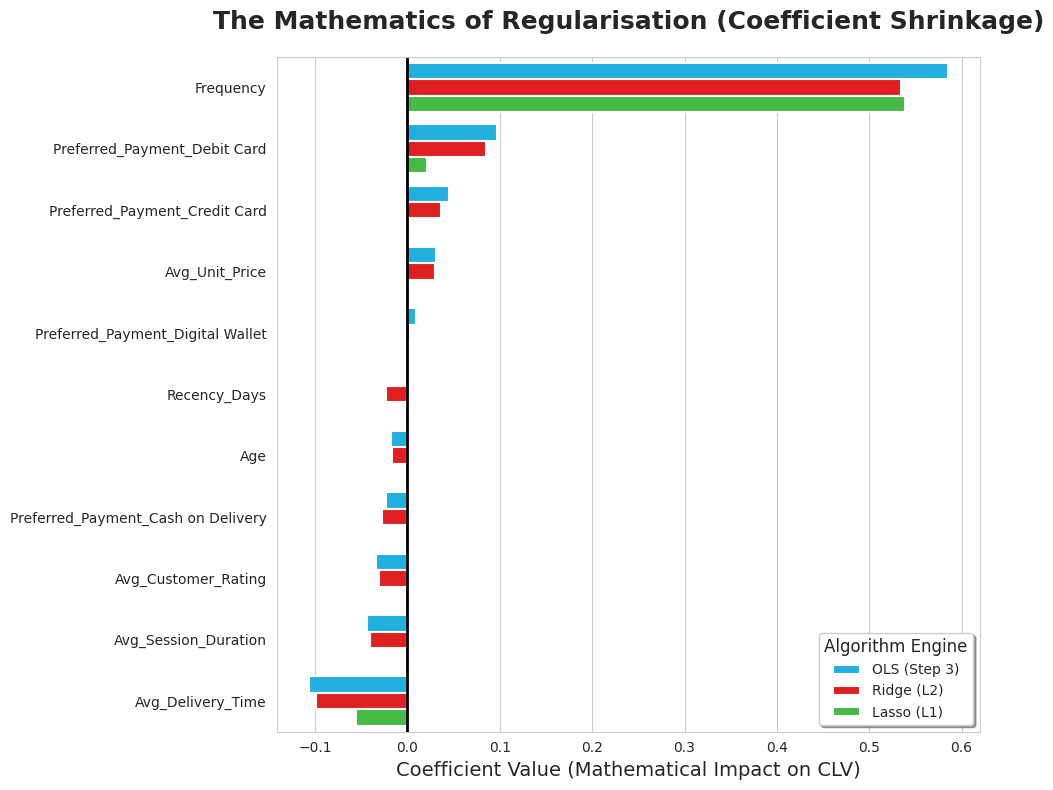

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import lasso_path
import numpy as np
import pandas as pd

# 1) Visualising the Coefficient Shrinkage
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 8))

df_melted = coefficients_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')
df_melted['Abs_Coefficient'] = df_melted['Coefficient'].abs()

top_features = df_melted.groupby('Feature')['Abs_Coefficient'].mean().sort_values(ascending=False).head(15).index
df_melted_top = df_melted[df_melted['Feature'].isin(top_features)]

feature_order = df_melted_top[df_melted_top['Model'] == 'OLS (Step 3)'].sort_values(by='Coefficient', ascending=False)['Feature']

palette = ['deepskyblue', 'red', 'limegreen']
sns.barplot(
    data = df_melted_top, y='Feature', x='Coefficient', hue='Model',
    palette = palette, ax=ax, edgecolor='white', linewidth=1.5, order=feature_order
)

plt.title('The Mathematics of Regularisation (Coefficient Shrinkage)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Coefficient Value (Mathematical Impact on CLV)', fontsize=14)
plt.ylabel('')
plt.axvline(0, color='black', linewidth=2)
plt.legend(title='Algorithm Engine', fontsize=10, title_fontsize=12, facecolor='white', framealpha=1, shadow=True)

plt.tight_layout()
plt.show()

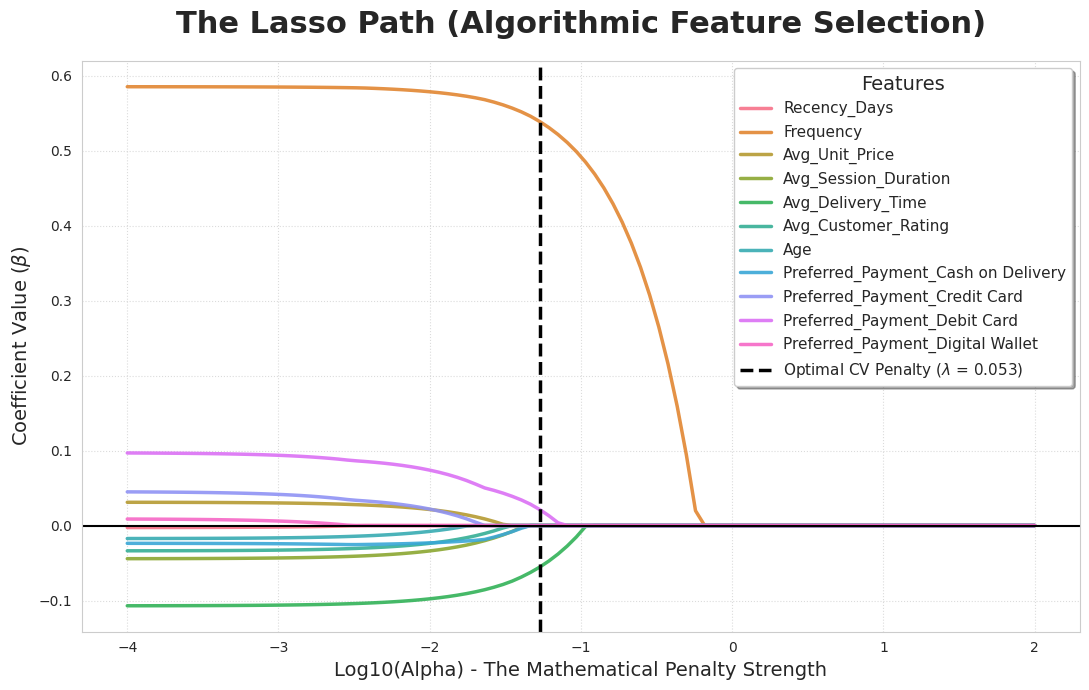

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import lasso_path
import numpy as np
import pandas as pd

# 2) The Lasso Path (Mathematical Feature Selection)
alphas_lasso_path, coefs_lasso_path, _ = lasso_path(X_scaled_sklearn, y, alphas=np.logspace(2, -4, 100))

# 2.1) Visualising Logarithmic Feature Trajectory Lines
plt.figure(figsize=(11, 7))

num_features = coefs_lasso_path.shape[0]
colors = sns.color_palette('husl', n_colors=num_features)

for i in range (num_features):
  plt.plot(
      np.log10(alphas_lasso_path), coefs_lasso_path[i],
      color=colors[i], linewidth=2.5, alpha=0.9,
      label=coefficients_df['Feature'].iloc[i]
  )

# 2.2) Visualising Our Optimal Lasso Alpha (Vertical Dashed Line)
optimal_alpha_log = np.log10(lasso_cv.alpha_)
plt.axvline(optimal_alpha_log, color='black', linestyle='--', linewidth=2.5,
            label=rf"Optimal CV Penalty ($\lambda$ = {lasso_cv.alpha_:.3f})")

plt.title('The Lasso Path (Algorithmic Feature Selection)', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Log10(Alpha) - The Mathematical Penalty Strength', fontsize=14)
plt.ylabel(rf'Coefficient Value ($\beta$)', fontsize=14)
plt.axhline(0, color='black', linewidth=1.5)

plt.legend(loc='upper right', fontsize=11, facecolor='white',
           framealpha=1, shadow=True, title='Features', title_fontsize=14)
plt.grid(True, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.show()

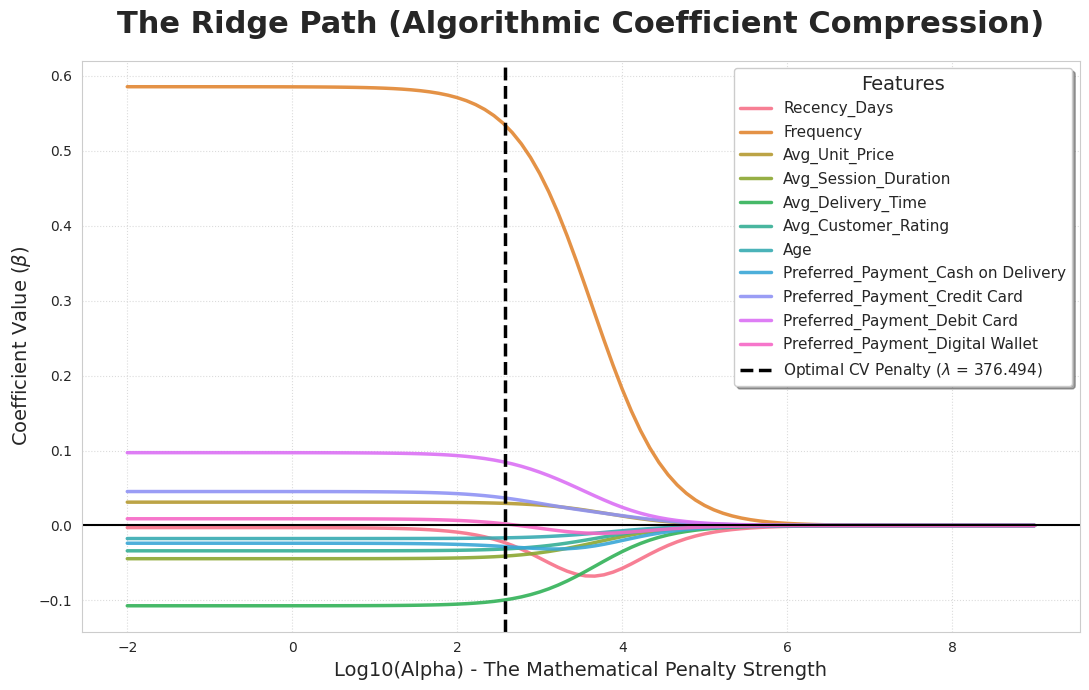

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd

# 1) Generating Penalty Strengths
alphas_ridge_path = np.logspace(-2, 9, 100)
coefs_ridge_path = []

# 2) Ridge Model Fitting Loop
for a in alphas_ridge_path:
  ridge_temp = Ridge(alpha=a)
  ridge_temp.fit(X_scaled_sklearn, y)
  coefs_ridge_path.append(ridge_temp.coef_)

coefs_ridge_path = np.array(coefs_ridge_path).T

# 3) Visualising the Ridge Path
plt.figure(figsize=(11, 7))
num_features = len(coefficients_df['Feature'])
colors = sns.color_palette('husl', num_features)

# 2.1) Visualising Trajectory Lines of Features
for i in range(coefs_ridge_path.shape[0]):
  plt.plot(
      np.log10(alphas_ridge_path), coefs_ridge_path[i],
      color=colors[i % 20], linewidth=2.5, alpha=0.9,
      label=coefficients_df['Feature'].iloc[i]
  )

# 2.2) Visualising Our Optimal Ridge Alpha (Vertical Dashed Line)
optimal_ridge_log = np.log10(ridge_cv.alpha_)
plt.axvline(optimal_ridge_log, color='black', linestyle='--', linewidth=2.5,
            label=rf"Optimal CV Penalty ($\lambda$ = {ridge_cv.alpha_:.3f})")

plt.title('The Ridge Path (Algorithmic Coefficient Compression)', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Log10(Alpha) - The Mathematical Penalty Strength', fontsize=14)
plt.ylabel(rf'Coefficient Value ($\beta$)', fontsize=14)
plt.axhline(0, color='black', linewidth=1.5)

plt.legend(loc='upper right', fontsize=11, facecolor='white', title='Features', title_fontsize=14, framealpha=1, shadow=True)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# **Step 5: Two Stage Hurdle Model (XGBoost Classifier & Regressor)**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

categorical_cols = ['Preferred_Payment']
customer_df_encoded = pd.get_dummies(customer_df, columns=categorical_cols, drop_first=True, dtype=int)

X_raw_xgb = customer_df_encoded.drop(columns=['Customer_ID', 'Monetary_CLV', 'Log_Monetary_CLV'])

y = customer_df['Log_Monetary_CLV']
y_binary = (y > 0).astype(int)

scaler_xgb = StandardScaler()
X_scaled_xgb = scaler_xgb.fit_transform(X_raw_xgb)

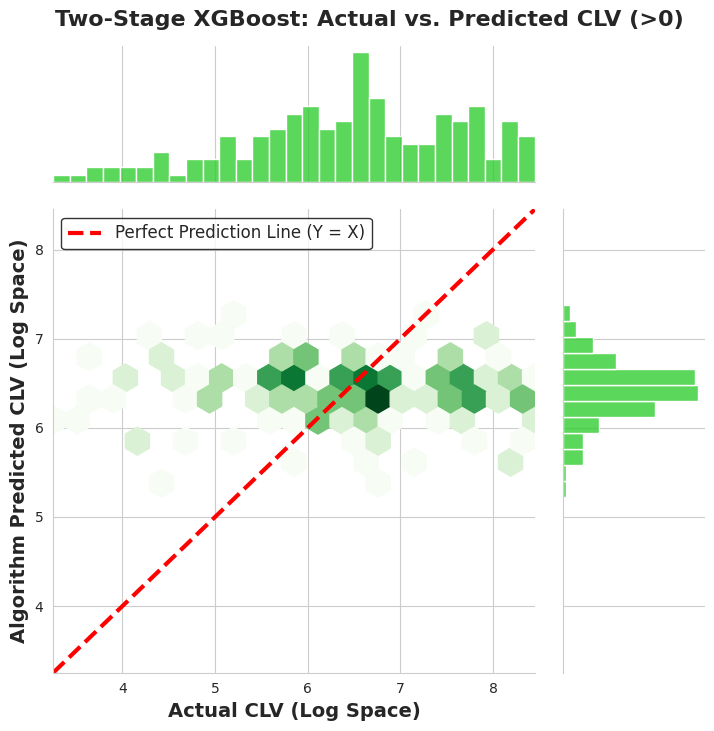

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X_scaled_xgb, y, y_binary, test_size=0.2, random_state=42
)

neg_class_count = (y_train_bin == 0).sum()
pos_class_count = (y_train_bin == 1).sum()
spw = neg_class_count / pos_class_count

# Stage 1: The Classifier
xgb_clf_balanced = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss'
)
xgb_clf_balanced.fit(X_train, y_train_bin)

mask_train_pos = y_train > 0
y_train_buyers_only = y_train[mask_train_pos]
whale_limit_log = np.percentile(y_train_buyers_only, 90)

mask_train_core = (y_train > 0) & (y_train <= whale_limit_log)
X_train_core = X_train[mask_train_core]
y_train_core = y_train[mask_train_core]

# Stage 2: The Regressor
xgb_reg = XGBRegressor(
    n_estimators = 200,
    max_depth=5,
    learning_rate=0.05,
    objective='reg:absoluteerror',
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train_core, y_train_core)

pred_will_buy = xgb_clf_balanced.predict(X_test)
pred_how_much = xgb_reg.predict(X_test)
y_pred_log_final = pred_will_buy * pred_how_much

# Visualising the Joint Plot - Actual vs. Predicted (CLV > 0)
mask_plot = (y_test > 0) & (y_test <= whale_limit_log) & (y_pred_log_final > 0)
y_test_plot = y_test[mask_plot]
y_pred_plot = y_pred_log_final[mask_plot]

min_val=min(y_test_plot.min(), y_pred_plot.min())
max_val=max(y_test_plot.max(), y_pred_plot.max())
fixed_bins = np.linspace(min_val, max_val, 30)

sns.set_style('whitegrid')
g = sns.jointplot(
    x=y_test_plot, y=y_pred_plot, kind='hex', gridsize=20,
    cmap='Greens', mincnt=1, height=7, ratio=3,
    xlim=(min_val, max_val), ylim=(min_val, max_val),
    joint_kws=dict(extent=[min_val, max_val, min_val, max_val]),
    marginal_kws=dict(bins=fixed_bins, fill=True, color='limegreen', alpha=0.8)
)

g.ax_joint.plot(
    [min_val, max_val], [min_val, max_val],
    color='red', linestyle='--', linewidth=3,
    label='Perfect Prediction Line (Y = X)'
)

g.fig.suptitle('Two-Stage XGBoost: Actual vs. Predicted CLV (>0)', fontsize=16, fontweight='bold', y=1.03)
g.ax_joint.set_xlabel('Actual CLV (Log Space)', fontsize=14, fontweight='bold')
g.ax_joint.set_ylabel('Algorithm Predicted CLV (Log Space)', fontsize=14, fontweight='bold')
g.ax_joint.legend(loc='upper left', fontsize=12, facecolor='white', edgecolor='black')

plt.show()

# **Calcualting the Metric Values**

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             r2_score, mean_absolute_error, median_absolute_error)
import numpy as np
import pandas as pd

y_probs = xgb_clf_balanced.predict_proba(X_test)[:, 1]
custom_threshold = 0.465
pred_will_buy_opt = (y_probs >= custom_threshold).astype(int)

clf_acc = accuracy_score(y_test_bin, pred_will_buy_opt)
clf_prec = precision_score(y_test_bin, pred_will_buy_opt, zero_division=0)
clf_rec = recall_score(y_test_bin, pred_will_buy_opt, zero_division=0)

mask_tp_core = (y_test > 0) & (y_test <= whale_limit_log) & (pred_will_buy > 0)

y_test_tp_core = y_test[mask_tp_core]
y_pred_tp_core = pred_how_much[mask_tp_core]

r2_reg_log = r2_score(y_test_tp_core, y_pred_tp_core)

y_test_tp_TL = np.expm1(y_test_tp_core)
y_pred_tp_TL = np.expm1(y_pred_tp_core)

mae_tp_TL = mean_absolute_error(y_test_tp_TL, y_pred_tp_TL)
medae_tp_TL = median_absolute_error(y_test_tp_TL, y_pred_tp_TL)

report_data = {
    'Metric Type': [
        'Classification Accuracy',
        f'Classification Precision (Thresh: {custom_threshold})',
        f'Classification Recall (Thresh: {custom_threshold})',
        'Regression R-Squared (True Buyers)',
        'Regression Median Error (MedAE)',
        'Regression Average Error (MAE)'
    ],
    'Results': [
        f"{clf_acc * 100:.1f}%",
        f"{clf_prec * 100:.1f}%",
        f"{clf_rec * 100:.1f}%",
        f"{r2_reg_log * 100:.1f}%",
        f"{medae_tp_TL:,.2f} TL",
        f"{mae_tp_TL:,.2f} TL"
    ]
}

diagnostic_report = pd.DataFrame(report_data)

print(f'---   Two-Stage Report (Optimized {custom_threshold} Threshold):')
print(diagnostic_report.to_string(index=False))


---   Two-Stage Report (Optimized 0.465 Threshold):
                             Metric Type   Results
                 Classification Accuracy     54.8%
Classification Precision (Thresh: 0.465)     52.6%
   Classification Recall (Thresh: 0.465)     53.3%
      Regression R-Squared (True Buyers)    -11.3%
         Regression Median Error (MedAE) 453.75 TL
          Regression Average Error (MAE) 839.58 TL
